In [1]:
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import pipeline
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from stargazer.stargazer import Stargazer
import matplotlib.font_manager as fm
from nltk.tokenize import sent_tokenize
import nltk
import torch
nltk.download('punkt_tab')
nltk.download('punkt')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/kojomanu/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /Users/kojomanu/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [3]:
# Loading USMPD data
usmpd = pd.read_csv('mps.csv', parse_dates=['Date']).set_index('Date')
usmpd

,STMT,PC,ME
Date,,,
1994-02-04,0.074458,NaN,0.079332
1994-03-22,-0.025795,NaN,-0.026742
1994-04-18,0.059224,NaN,0.063562
1994-05-17,-0.019003,NaN,-0.019109
1994-07-06,0.006800,NaN,0.008700
...,...,...,...
2025-06-18,-0.007840,0.014645,0.003134
2025-07-30,0.001229,0.056218,0.048239
2025-09-17,-0.023021,0.024393,-0.003979


Text(0, 0.5, 'Percentage Points')

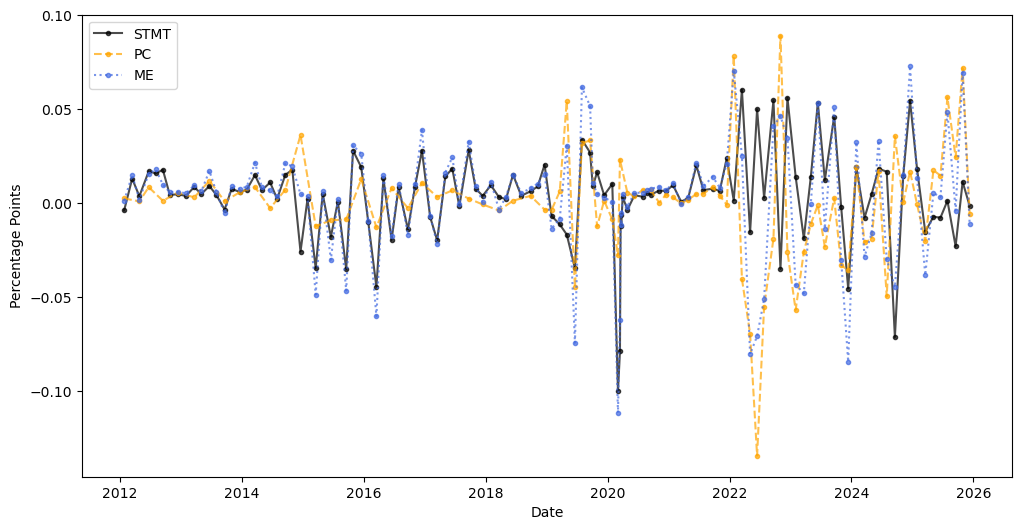

In [4]:
# Plotting monetary policy surprises over time
# From 2012 onwards because thats when the PC surprises start

usmpd12 = usmpd[usmpd.index >= '2012-01-01']

plt.figure(figsize=(12, 6))
plt.plot(usmpd12.index, usmpd12['STMT'], linestyle='solid', alpha=0.7, label='STMT', marker = '.', color = 'black')
plt.plot(usmpd12['PC'].dropna().index, usmpd12['PC'].dropna(), linestyle='dashed', alpha=0.7, label='PC', color = 'orange', marker = '.')
plt.plot(usmpd12.index, usmpd12['ME'], linestyle='dotted', alpha=0.7, label='ME', marker = '.', color = 'royalblue')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Percentage Points')
# plt.title('Monetary Policy Surprises Over Time')

In [5]:
usmpd.corr()

,STMT,PC,ME
STMT,1.000000,-0.125272,0.928242
PC,-0.125272,1.000000,0.644757
ME,0.928242,0.644757,1.000000


In [6]:
# Loading calculated statement, press conference, and monetary surprise data
statements = pd.read_excel('USMPD.xlsx', sheet_name='Statements', parse_dates=['Date']).set_index('Date')
press_conference = pd.read_excel('USMPD.xlsx', sheet_name='Press Conferences', parse_dates=['Date']).set_index('Date')
monetary_events = pd.read_excel('USMPD.xlsx', sheet_name='Monetary Events', parse_dates=['Date']).set_index('Date')

In [7]:
# Joining dataframes
stmt = statements.join(usmpd['STMT'], how = 'left')
pc = press_conference.join(usmpd['PC'], how = 'left')
me = monetary_events.join(usmpd['ME'], how = 'left')

# Analysis

## ME Surprise on SP500

In [8]:
# Monetary Event Surprise on SP500
y = me[me['SP500'].notna()]['SP500']
x = me[me['SP500'].notna()]['ME']
x = sm.add_constant(x)

model = sm.OLS(y, x).fit(cov_type='HC3')  # Using robust standard errors

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  SP500   R-squared:                       0.156
Model:                            OLS   Adj. R-squared:                  0.153
Method:                 Least Squares   F-statistic:                     21.59
Date:                Sun, 08 Mar 2026   Prob (F-statistic):           5.42e-06
Time:                        22:05:34   Log-Likelihood:                -310.98
No. Observations:                 256   AIC:                             626.0
Df Residuals:                     254   BIC:                             633.1
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0010      0.051      0.020      0.9

## ME Surprise on Treasury Yields

In [9]:
cols = ['UST3M', 'UST6M', 'UST2Y', 'UST5Y', 'UST10Y', 'UST30Y']
rows = []

for col in cols:
    y = me[me[col].notna()][col]
    x = me[me[col].notna()]['ME']
    x = sm.add_constant(x)

    model = sm.OLS(y, x).fit(cov_type='HC3')  # Using robust standard errors
    betas = model.params['ME']
    ci_low, ci_high = model.conf_int(alpha=0.05).loc['ME']
    rows.append({'Maturity': col, 
                 'Beta': betas,
                 'CI_Low': ci_low,
                 'CI_High': ci_high})
    
results = pd.DataFrame(rows)

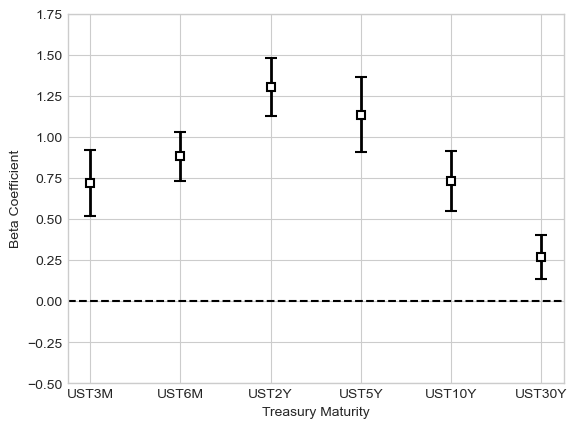

In [10]:
yerr = [
    results['Beta'] - results['CI_Low'],
    results['CI_High'] - results['Beta']
]
plt.style.use('seaborn-v0_8-whitegrid')
# plt.scatter(results['Maturity'], results['Beta'], marker='s', s=5, label='Beta Coefficient', color='black')
# plt.fill_between(results['Maturity'], results['CI_Low'], results['CI_High'], color='gray', alpha=0.3, label='95% Confidence Interval')
plt.xlabel('Treasury Maturity')
plt.ylabel('Beta Coefficient')
# plt.title('ME Surprise on Treasury Yields')
plt.ylim(-0.5, 1.75)
plt.errorbar(results['Maturity'],
    results['Beta'],
    yerr=yerr,
    fmt='s',                    # square markers
    markersize=6,
    markeredgewidth=1.5,
    color='black',
    ecolor='black',
    elinewidth=2,
    capsize=4,
    label = 'Beta Coefficient with 95% CI',
    markeredgecolor='black',
    markerfacecolor='white',
    )
# plt.legend()
plt.axhline(0, color='black', linestyle='--')
plt.show()

## ME Surprise on TIPS Yields

In [11]:
cols = ['TIPS5Y', 'TIPS10Y', 'TIPS30Y']
rows = []

for col in cols:
    y = me[me[col].notna()][col]
    x = me[me[col].notna()]['ME']
    x = sm.add_constant(x)

    model = sm.OLS(y, x).fit(cov_type='HC3')  # Using robust standard errors
    betas = model.params['ME']
    ci_low, ci_high = model.conf_int(alpha=0.05).loc['ME']
    rows.append({'Maturity': col, 
                 'Beta': betas,
                 'CI_Low': ci_low,
                 'CI_High': ci_high})
    
results = pd.DataFrame(rows)

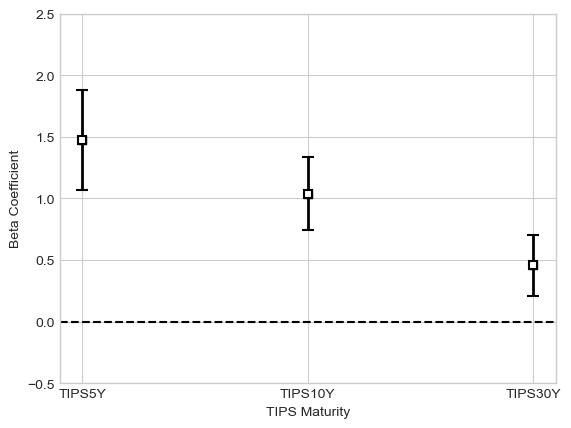

In [ ]:
yerr = yerr = [
    results['Beta'] - results['CI_Low'],
    results['CI_High'] - results['Beta']
]
plt.style.use('seaborn-v0_8-whitegrid')
plt.scatter(results['Maturity'], results['Beta'], marker='s', label='Beta Coefficient', color='black')
# plt.fill_between(results['Maturity'], results['CI_Low'], results['CI_High'], color='gray', alpha=0.3, label='95% Confidence Interval')
plt.xlabel('TIPS Maturity')
plt.ylabel('Beta Coefficient')
# plt.title('ME Surprise on TIPS Yields')
plt.ylim(-0.5, 2.5)
plt.errorbar(results['Maturity'],
    results['Beta'],
    yerr=yerr,
    fmt='s',
    markersize=6,
    markeredgewidth=1.5,
    color='black',
    ecolor='black',
    elinewidth=2,
    capsize=4,
    label = 'Beta Coefficient with 95% CI',
    markeredgecolor='black',
    markerfacecolor='white',
    )
# plt.legend()
plt.axhline(0, color='black', linestyle='--')
plt.show()

## Including Sentiment Scores

In [17]:
# Sentiment dataset from (Osowska & Wójcik, 2023)

sentiment = pd.read_csv('sentiment.csv')
sentiment['Date'] = pd.to_datetime(sentiment['Date'])  # Ensure 'Date' is in datetime format
sentiment_scores = sentiment[['Date', 'score_FinBERT']].copy() # Create a new DataFrame with 'Date' and 'score_FinBERT'
sentiment_scores['Date'] = sentiment_scores['Date'].dt.date  # Extract date w/out time
sentiment_scores = sentiment_scores.groupby('Date')['score_FinBERT'].first().reset_index() # Group by date and take first score
sentiment_scores.set_index('Date', inplace=True)

In [60]:
sentiment_scores.head()

,score_FinBERT
Date,
2001-03-20,-0.331197
2001-05-15,-0.168226
2001-06-27,-0.171036
2001-08-21,-0.217223
2001-10-02,-0.252074


### Loading current FOMC statement sentiment scores

In [93]:
# ── 1. Load FinBERT ──────────────────────────────────────────────────────────
finbert = pipeline("text-classification",
                   model="./finbert-tone-local",
                   top_k=None)

# ── 2. All FOMC statement URLs after 2023-06-14 ──────────────────────────────
def get_all_fomc_urls(cutoff: pd.Timestamp) -> dict:
    """Scrape all FOMC statement URLs after the cutoff date from the Fed website."""
    base = "https://www.federalreserve.gov"
    url  = f"{base}/monetarypolicy/fomc_historical_year.htm"
    
    urls = {}
    pages = [
        "https://www.federalreserve.gov/monetarypolicy/fomc_historical_year.htm",
        "https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm"  # current year
    ]
    
    for page in pages:
        resp = requests.get(page, timeout=10)
        soup = BeautifulSoup(resp.text, "html.parser")
        
        for link in soup.find_all("a", href=True):
            href = link["href"]
            # Match links like /newsevents/pressreleases/monetary20240918a.htm
            if "pressreleases/monetary" in href and href.endswith("a.htm"):
                # Extract date from URL
                date_str = href.split("monetary")[1][:8]  # gets YYYYMMDD
                date = pd.to_datetime(date_str, format="%Y%m%d")
                if date > cutoff:
                    full_url = base + href if href.startswith("/") else href
                    urls[date.strftime("%Y-%m-%d")] = full_url
    
    return dict(sorted(urls.items()))

cutoff = pd.to_datetime(sentiment_scores.index[-1])

# Replace the hardcoded FOMC_URLS dict with:
FOMC_URLS = get_all_fomc_urls(cutoff)

# ── 3. Fetch & score helpers ─────────────────────────────────────────────────
def fetch_fomc_text(url: str) -> str:
    resp = requests.get(url, timeout=10)
    soup = BeautifulSoup(resp.text, "html.parser")
    body = soup.find("div", {"class": "col-xs-12 col-sm-8 col-md-8"})
    return body.get_text(separator=" ").strip() if body else ""

def score_sentence(sent: str) -> dict:
    results = finbert(sent[:512], top_k=None)
    return {r['label']: r['score'] for r in results}

def score_fomc_statement(text: str) -> float:
    sentences = sent_tokenize(text)
    net_scores = []
    for sent in sentences:
        sent = sent.strip()
        if len(sent) < 10:
            continue
        scores = score_sentence(sent)
        net_scores.append(scores['Positive'] - scores['Negative'])
    return float(np.mean(net_scores))

# ── 4. Score new statements ───────────────────────────────────────────────────
new_rows = []
for date_str, url in FOMC_URLS.items():
    date = pd.to_datetime(date_str)
    if date <= cutoff:
        continue
    # Skip if already in the dataset
    if date in sentiment_scores.index:
        print(f"Skipping {date_str} — already in dataset")
        continue

    print(f"Scoring {date_str}...")
    text = fetch_fomc_text(url)
    if not text:
        print(f"  Could not fetch {date_str}")
        continue

    net = score_fomc_statement(text)
    new_rows.append({"date": date, "score_FinBERT": net})
    print(f"  => score_FinBERT={net:+.4f}")

# ── 5. Append & save ──────────────────────────────────────────────────────────
if new_rows:
    new_df = pd.DataFrame(new_rows)
    new_df.index = pd.to_datetime(new_df['date'])
    new_df.drop(columns=['date'], inplace=True)
    current_sentiment = pd.concat([sentiment_scores, new_df])
    current_sentiment.index = pd.to_datetime(current_sentiment.index)
    current_sentiment = current_sentiment.sort_index()
    # current_sentiment.to_csv("your_file.csv", index=False)
    print(f"\nDone — added {len(new_rows)} new rows to your_file.csv")
else:
    print("No new rows to add.")

Device set to use cpu


Scoring 2023-07-26...
  => score_FinBERT=+0.0991
Scoring 2023-09-20...
  => score_FinBERT=+0.0098
Scoring 2023-11-01...
  => score_FinBERT=+0.0790
Scoring 2023-12-13...
  => score_FinBERT=-0.0253
Scoring 2024-01-31...
  => score_FinBERT=+0.0363
Scoring 2024-03-20...
  => score_FinBERT=+0.0507
Scoring 2024-05-01...
  => score_FinBERT=+0.0123
Scoring 2024-06-12...
  => score_FinBERT=+0.1088
Scoring 2024-07-31...
  => score_FinBERT=-0.0063
Scoring 2024-09-18...
  => score_FinBERT=+0.0471
Scoring 2024-11-07...
  => score_FinBERT=+0.1291
Scoring 2024-12-18...
  => score_FinBERT=+0.1215
Scoring 2025-01-29...
  => score_FinBERT=+0.0783
Scoring 2025-03-19...
  => score_FinBERT=+0.0447
Scoring 2025-05-07...
  => score_FinBERT=+0.0720
Scoring 2025-06-18...
  => score_FinBERT=+0.0785
Scoring 2025-07-30...
  => score_FinBERT=-0.0408
Scoring 2025-08-22...
  => score_FinBERT=+0.1165
Scoring 2025-09-17...
  => score_FinBERT=-0.1507
Scoring 2025-10-29...
  => score_FinBERT=-0.0453
Scoring 2025-12-10..

In [94]:
current_sentiment.tail()

,score_FinBERT
2025-08-22,0.116467
2025-09-17,-0.150662
2025-10-29,-0.045346
2025-12-10,-0.038488
2026-01-28,-0.044714


Text(0, 0.5, 'Sentiment Score (FinBERT)')

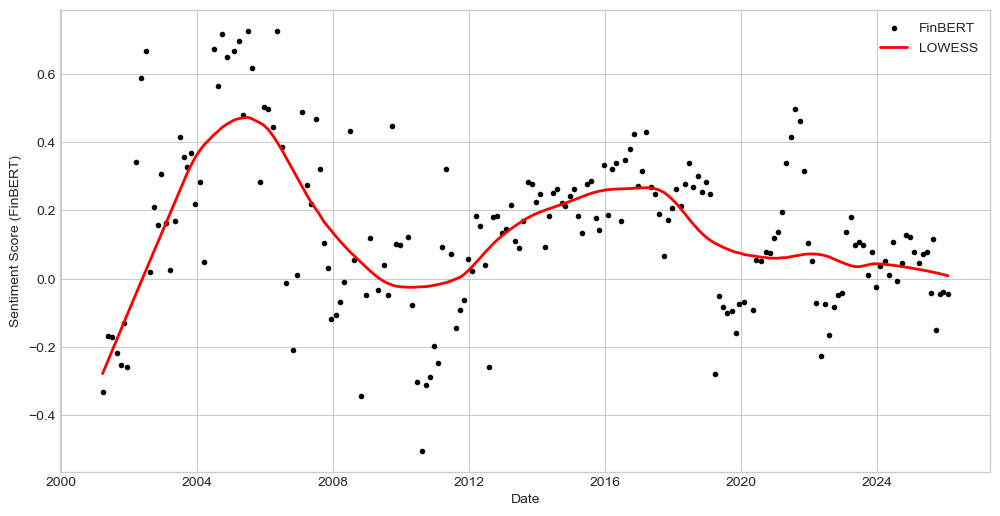

In [95]:
lowess = sm.nonparametric.lowess(current_sentiment['score_FinBERT'], 
                                  current_sentiment.index.astype(np.int64), 
                                  frac=0.2)

plt.figure(figsize=(12, 6))
plt.scatter(current_sentiment.index, current_sentiment['score_FinBERT'], label='FinBERT', marker = '.', color = 'black')
plt.plot(current_sentiment.index, lowess[:, 1], 
          color='red', linewidth=2, label='LOWESS')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Sentiment Score (FinBERT)')
# plt.title('FOMC Statement Sentiment Over Time')

## ME Surprise & Sentiment on SP500

In [ ]:
# Insert FinBERT scores into me dataset
me['score_FinBERT'] = current_sentiment['score_FinBERT']
me_bert = me[me['score_FinBERT'].notna()]

In [85]:
X = me_bert[['ME', 'score_FinBERT']]
X = sm.add_constant(X)
y = me_bert['SP500']
model = sm.OLS(y, X).fit(cov_type='HC3')  # Using robust standard errors
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  SP500   R-squared:                       0.259
Model:                            OLS   Adj. R-squared:                  0.251
Method:                 Least Squares   F-statistic:                     28.23
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           1.94e-11
Time:                        00:19:48   Log-Likelihood:                -170.80
No. Observations:                 190   AIC:                             347.6
Df Residuals:                     187   BIC:                             357.3
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.0121      0.058     -0.211

## ME Surprise & Sentiment on US10Y

In [87]:
X = me_bert[['ME', 'score_FinBERT']]
X = sm.add_constant(X)
y = me_bert['UST10Y']
model = sm.OLS(y, X).fit(cov_type='HC3')  # Using robust standard errors
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 UST10Y   R-squared:                       0.357
Model:                            OLS   Adj. R-squared:                  0.350
Method:                 Least Squares   F-statistic:                     27.72
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           2.85e-11
Time:                        00:20:59   Log-Likelihood:                 371.59
No. Observations:                 190   AIC:                            -737.2
Df Residuals:                     187   BIC:                            -727.4
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.0044      0.003     -1.401

## ME Surprise, Sentiment and Interaction on SP500

In [56]:
# Introduce interaction term between sentiment and ED4 (change in eurodollar 4-quarter futures)
interaction_df = me[me['score_FinBERT'].notna() & me['ED4'].notna()].copy()
interaction_df['interaction'] = interaction_df['score_FinBERT'] * interaction_df['ED4']

In [89]:
X = interaction_df[['score_FinBERT', 'ED4', 'interaction', 'ME']]
y = interaction_df['SP500']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit(cov_type='HC3')  # Using robust standard errors
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  SP500   R-squared:                       0.259
Model:                            OLS   Adj. R-squared:                  0.243
Method:                 Least Squares   F-statistic:                     14.29
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           3.48e-10
Time:                        00:22:54   Log-Likelihood:                -170.80
No. Observations:                 190   AIC:                             351.6
Df Residuals:                     185   BIC:                             367.8
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.0140      0.062     -0.228

## ME Surprise, Sentiment and Interaction on UST10Y

In [91]:
X = interaction_df[['score_FinBERT', 'ED4', 'interaction', 'ME']]
y = interaction_df['UST10Y']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit(cov_type='HC3')  # Using robust standard errors
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 UST10Y   R-squared:                       0.586
Model:                            OLS   Adj. R-squared:                  0.577
Method:                 Least Squares   F-statistic:                     51.13
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           6.07e-29
Time:                        00:26:09   Log-Likelihood:                 413.40
No. Observations:                 190   AIC:                            -816.8
Df Residuals:                     185   BIC:                            -800.6
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0051      0.003      1.519